# 8. In the lab, a classifcation tree was applied to the Carseats data set after converting Sales into a qualitative response variable. Now we will seek to predict Sales using regression trees and related approaches, treating the response as a quantitative variable.

In [35]:
!pip install ISLP

In [36]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from ISLP import load_data
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.tree import DecisionTreeRegressor, plot_tree
from sklearn.metrics import mean_squared_error
from sklearn.ensemble import BaggingRegressor, RandomForestRegressor
from sklearn.tree import export_graphviz
import pydotplus
from IPython.display import Image

## (a) Split the data set into a training set and a test set.

In [37]:
data = load_data('Carseats')

data = pd.get_dummies(data, drop_first=True)

X = data.drop('Sales', axis=1)
y = data['Sales']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

print(f"原始數據集大小: {data.shape[0]}")
print(f"訓練集大小: {X_train.shape[0]}")
print(f"測試集大小: {X_test.shape[0]}")

原始數據集大小: 400
訓練集大小: 280
測試集大小: 120


## (b) Fit a regression tree to the training set. Plot the tree, and interpret the results. What test MSE do you obtain?

$$ 測試集 MSE = 5.0038 $$

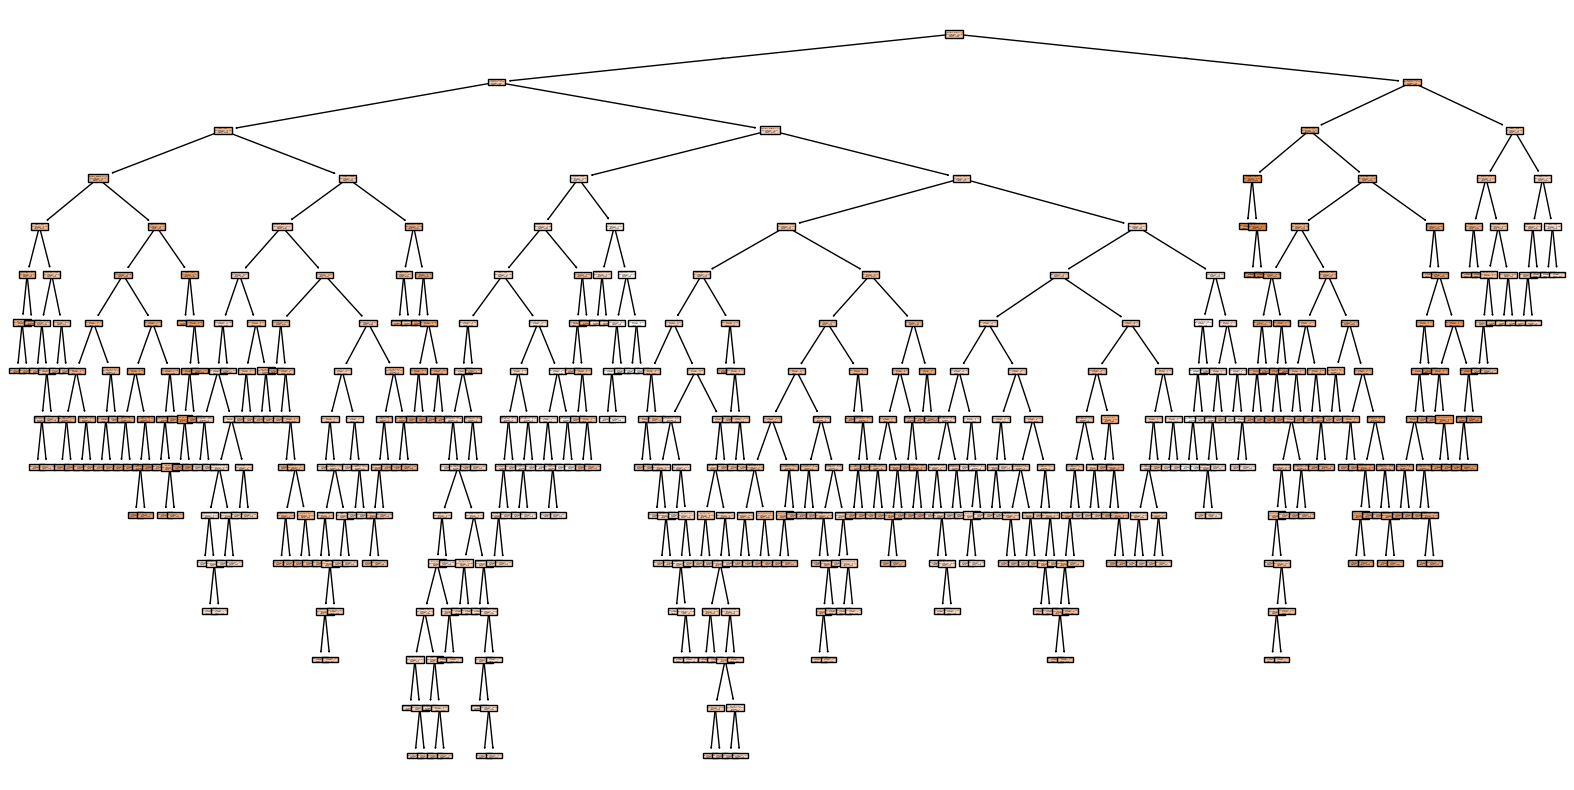

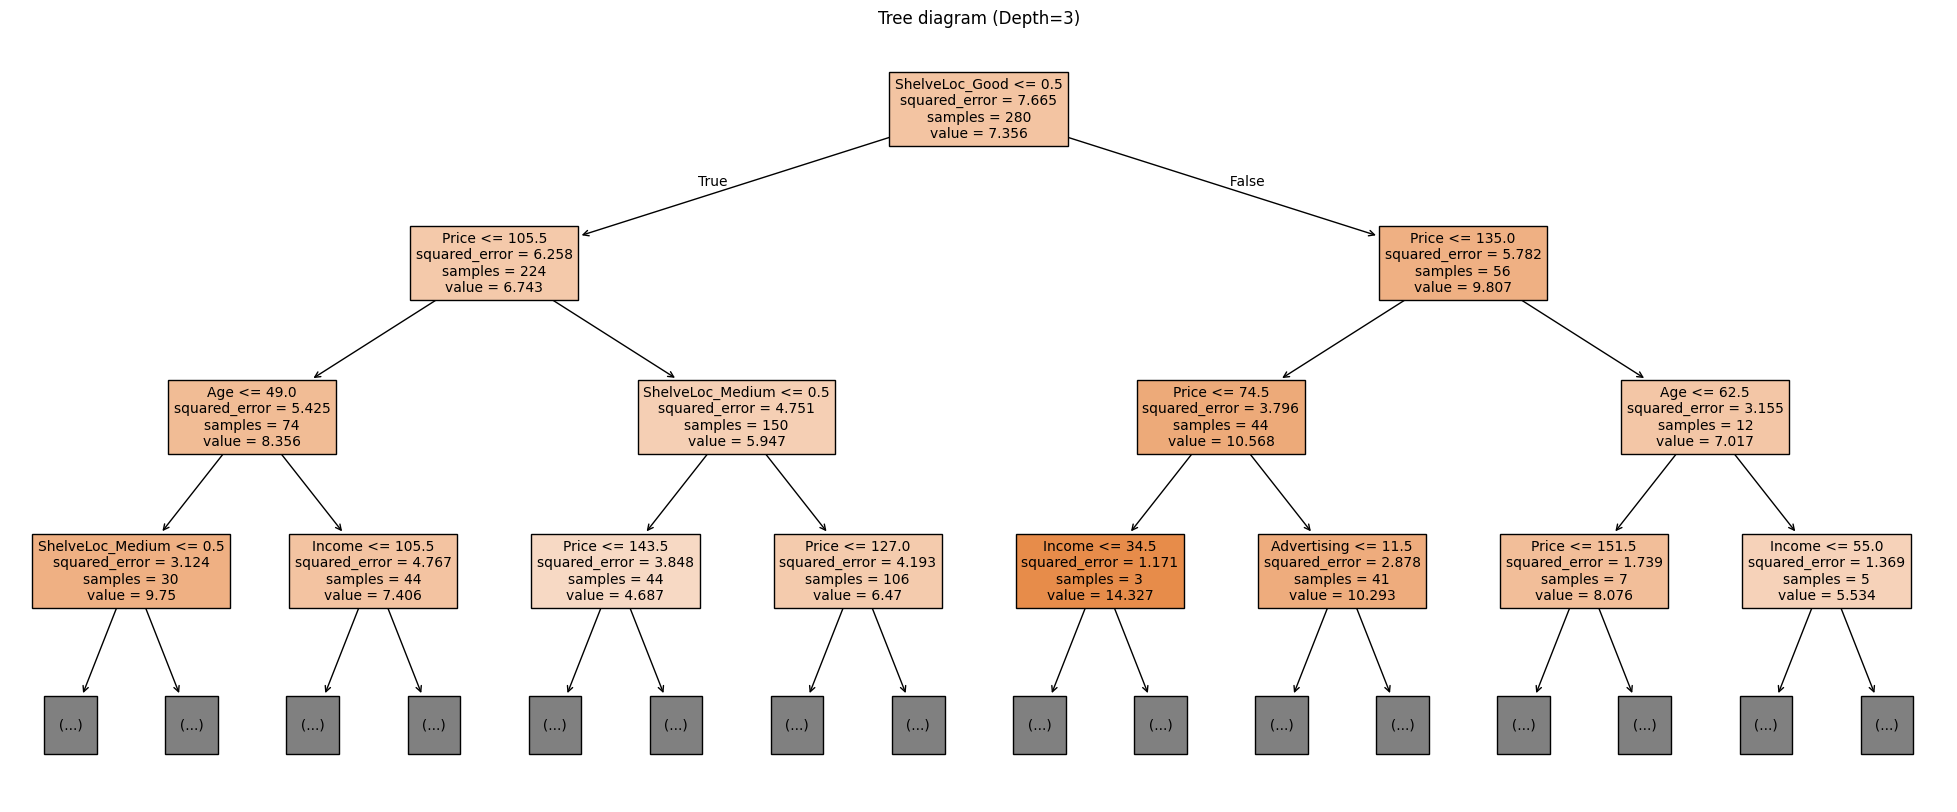


第一個分割變數: ShelveLoc_Good
分割值: 0.50

測試集 MSE: 5.0038


In [38]:
reg_tree = DecisionTreeRegressor(random_state=34)
reg_tree.fit(X_train, y_train)

plt.figure(figsize=(20,10))
plot_tree(reg_tree, feature_names=X.columns, filled=True)
plt.show()

plt.figure(figsize=(25, 10))
plot_tree(
    reg_tree,
    feature_names=X.columns.tolist(),
    filled=True,
    max_depth=3,
    fontsize=10
)
plt.title("Tree diagram (Depth=3)")
plt.show()

print(f"\n第一個分割變數: {X.columns[reg_tree.tree_.feature[0]]}")
print(f"分割值: {reg_tree.tree_.threshold[0]:.2f}")

y_pred_b = reg_tree.predict(X_test)
mse_b = mean_squared_error(y_test, y_pred_b)
print(f"\n測試集 MSE: {mse_b:.4f}")

## (c) Use cross-validation in order to determine the optimal level of tree complexity. Does pruning the tree improve the test MSE?

### Result
$$ 原本 MSE = 5.0038 $$
$$ 修剪後 MSE = 4.3948 $$

我們可以從結果明顯看出，修剪後的樹狀圖 MSE 減少了 0.6 左右，明顯改善了測試集。（可能因為減少了 Overfitting 的問題。）

In [39]:
path = reg_tree.cost_complexity_pruning_path(X_train, y_train)
ccp_alphas, impurities = path.ccp_alphas, path.impurities

mse_alphas = []
for ccp_alpha in ccp_alphas:
    pruned_tree = DecisionTreeRegressor(random_state=42, ccp_alpha=ccp_alpha)

    neg_mse_scores = cross_val_score(
        pruned_tree, X_train, y_train, scoring='neg_mean_squared_error', cv=5
    )
    mse_alphas.append(-np.mean(neg_mse_scores))
param_grid = {"max_depth": np.arange(1, 11)}
grid_tree = GridSearchCV(DecisionTreeRegressor(random_state=42), param_grid, cv=5, scoring='neg_mean_squared_error')
grid_tree.fit(X_train, y_train)

best_depth = grid_tree.best_params_['max_depth']
print("最佳樹深度:", best_depth)

# 使用最佳深度建立模型
pruned_tree = DecisionTreeRegressor(max_depth=best_depth, random_state=34)
pruned_tree.fit(X_train, y_train)
y_pred_pruned = pruned_tree.predict(X_test)
mse_pruned = mean_squared_error(y_test, y_pred_pruned)
print("剪枝後迴歸樹測試集 MSE:", mse_pruned)
optimal_alpha_idx = np.argmin(mse_alphas)
optimal_alpha = ccp_alphas[optimal_alpha_idx]

print(f"最佳 ccp_alpha: {optimal_alpha:.4f}")
print(f"對應的 CV MSE: {mse_alphas[optimal_alpha_idx]:.4f}")

best_pruned_tree = DecisionTreeRegressor(random_state=34, ccp_alpha=optimal_alpha)
best_pruned_tree.fit(X_train, y_train)

y_pred_c = best_pruned_tree.predict(X_test)
mse_c = mean_squared_error(y_test, y_pred_c)

print(f"測試集 MSE: {mse_c:.4f}")


最佳樹深度: 5
剪枝後迴歸樹測試集 MSE: 4.983377134133359
最佳 ccp_alpha: 0.0351
對應的 CV MSE: 5.1044
測試集 MSE: 4.3948


## (d) Use the bagging approach in order to analyze this data. What test MSE do you obtain? Use the feature_importance_ values to determine which variables are most important.

$$ Bagging-測試集 MSE: 2.5076 $$

In [40]:
bagging_model = BaggingRegressor(
    estimator=DecisionTreeRegressor(random_state=42),
    n_estimators=500,
    max_samples=1.0,
    random_state=34,
    n_jobs=-1
)
bagging_model.fit(X_train, y_train)

y_pred_d = bagging_model.predict(X_test)
mse_d = mean_squared_error(y_test, y_pred_d)
print(f"Bagging 測試集 MSE: {mse_d:.4f}")

feature_importances = np.mean([
    tree.feature_importances_ for tree in bagging_model.estimators_
], axis=0)

importance_df_d = pd.DataFrame({
    'Feature': X.columns,
    'Importance': feature_importances
}).sort_values(by='Importance', ascending=False)

print("\nBagging 最重要變數:")
print(importance_df_d.head(5))

Bagging 測試集 MSE: 2.5076

Bagging 最重要變數:
          Feature  Importance
4           Price    0.328355
7  ShelveLoc_Good    0.188284
5             Age    0.116973
0       CompPrice    0.105571
2     Advertising    0.072378


## (e) Use random forests to analyze this data. What test MSE do you obtain? Use the feature_importance_ values to determine which variables are most important. Describe the efect of m, the number of variables considered at each split, on the error rate obtained.

$$ 隨機森林（m=sqrt(p)）-測試集 MSE: 3.1265 $$

In [41]:
rf_model = RandomForestRegressor(
    n_estimators=500,
    max_features='sqrt',
    random_state=34,
    n_jobs=-1
)
rf_model.fit(X_train, y_train)

y_pred_e = rf_model.predict(X_test)
mse_e = mean_squared_error(y_test, y_pred_e)
print(f"隨機森林（m=sqrt(p)）測試集 MSE: {mse_e:.4f}")

importance_df_e = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf_model.feature_importances_
}).sort_values(by='Importance', ascending=False)

print("\n隨機森林最重要變數:")
print(importance_df_e.head(5))

p = X.shape[1]
m_values = {
    'Bagging (m=p)': p,
    'RF (m=sqrt(p))': int(np.sqrt(p)),
    'RF (m=p/3)': int(p / 3)
}

mse_results = {}
for name, m in m_values.items():
    if m == p:
        mse = mse_d
    else:
        temp_rf = RandomForestRegressor(
            n_estimators=500,
            max_features=m,
            random_state=34,
            n_jobs=-1
        )
        temp_rf.fit(X_train, y_train)
        y_pred_temp = temp_rf.predict(X_test)
        mse = mean_squared_error(y_test, y_pred_temp)
    mse_results[name] = mse

print("\n在我們的測試中 m 對錯誤率的影響:")
for name, mse in mse_results.items():
    print(f"- {name} (m={m_values[name]}): MSE = {mse:.4f}")

隨機森林（m=sqrt(p)）測試集 MSE: 3.1265

隨機森林最重要變數:
          Feature  Importance
4           Price    0.252220
7  ShelveLoc_Good    0.141629
5             Age    0.131485
0       CompPrice    0.095219
2     Advertising    0.093183

在我們的測試中 m 對錯誤率的影響:
- Bagging (m=p) (m=11): MSE = 2.5076
- RF (m=sqrt(p)) (m=3): MSE = 3.1265
- RF (m=p/3) (m=3): MSE = 3.1265


## (f) Now analyze the data using BART, and report your results.
$$ Bart-測試集 MSE: 1.2425 $$

In [42]:
from ISLP.bart import BART
from sklearn.metrics import mean_squared_error
import numpy as np

X_train_processed = X_train.astype(float).fillna(X_train.mean(numeric_only=True))
X_test_processed = X_test.astype(float).fillna(X_test.mean(numeric_only=True))

bart_model = BART(burnin=50, ndraw=500, random_state=34)
bart_model.fit(X_train_processed.values, y_train.values)

y_pred_f = bart_model.predict(X_test_processed.values)

mse_f = mean_squared_error(y_test, y_pred_f)
print(f"ISLP BART 測試集 MSE: {mse_f:.4f}")

# lower_bound = np.quantile(y_pred_f, 0.025, axis=1)
# upper_bound = np.quantile(y_pred_f, 0.975, axis=1)

# print(f"預測值的平均 95% 區間寬度: {np.mean(upper_bound - lower_bound):.4f}")

ISLP BART 測試集 MSE: 1.2425


# Introduction

### 結果
| 模型 (Model) | 參數／優化 | 測試集均方誤差 (Test MSE) |
|--------------|------------|----------------------------|
| 迴歸樹 | 未優化 | 5.0038 |
| 迴歸樹 | 剪枝 (Pruning) | 4.3948 |
| Bagging | m = p | 2.5076 |
| 隨機森林 | m ≈ p， m 較小 | 3.1265 |
| BART | 貝氏集成 | 1.2425 |

### 討論
- 剪枝後的 MSE 與未剪枝的 MSE 較低，顯示模型隊訓練數據存在 Overfitting，因此適當的剪枝有良好的效果

- Bagging 和 RF 方法使 MSE 顯著下降，數據集的預測問題主要由高方差引起，因此我們透過將低方差。

- Bagging 和 RF 中，較大的 p 導致較低的 MSE。與 p 較低較好的印象不符，說明數據中可能存在少數極其強勢的變數，隨機森林限制變數採樣 ($m < p$) 反而增加了模型的偏差，影響了整體性能。

- BART 表現最佳，是所有模型中性能最好的，遠優於次好的 Bagging，這個方法同時有效的平衡了偏差與方差。